In [1]:
import numpy as np
import pandas as pd
import sys

from astropy.coordinates import Galactic, ICRS
from astropy import units as u
from modules.vr_opt import VrOpt

import nbimporter
import visualisations
import consensus_clusterings

sys.path.append('/Users/lui/Documents/3_semestr/Project/code/local-clustering/SemiMetricClustering')
from SemiMetricDensity import SemiMetricDensity

import square_grid
import shell_grid

In [2]:
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:grey']
zorders = [2, 2, 2, 2, 2, 1]
alphas = [0.9, 0.9, 0.9, 0.9, 0.9, 0.3]
log = True

# Create 6D Gaussian data
np.random.seed(42) 
n = 500# 1000
X_bg = (np.random.rand(n*5, 6) - 0.5) * 50 #background dataset of random points uniformly distributed 6D

mu = np.array([-5, 5, 5, 5, -5, 5]) #first 3 for average position of the Cluster in 3D(XYZ). Last 3 for average velocities in (VxVyVz)
c_xx = c_yy = 20 #Variance of the average in x and y.
c_xy = 15 # correlation of x and y, positive -> there is a correlation 
c_zz = 3 #Variance in z 
c_uvw = 1
cov = np.diag([c_xx, c_yy, c_zz, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy #makes positive correlation of x and y
# Add signal
X_sig_1 = np.random.multivariate_normal(mu, cov, n//2) #generate n/2 data points based on mu and cov

# Second cluster
mu_2 = np.array([5, -5, -5, -5, 5, -5])
c_xx_2 = c_yy = 20
c_xy_2 = -15
c_zz_2 = 3
cov = np.diag([c_xx_2, c_yy, c_zz_2, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy_2
X_sig_2 = np.random.multivariate_normal(mu_2, cov, n//2)

# Additional clusters' parameters
# Cluster 3
mu_3 = np.array([10, -10, -10, -10, 10, -10])
c_xx_3 = c_yy_3 = 25 # More spread in X-Y plane
c_xy_3 = 10
c_zz_3 = 4
cov_3 = np.diag([c_xx_3, c_yy_3, c_zz_3, c_uvw, c_uvw, c_uvw])
cov_3[0, 1] = cov_3[1, 0] = c_xy_3
X_sig_3 = np.random.multivariate_normal(mu_3, cov_3, n//2)

# Cluster 4
mu_4 = np.array([-7, -7, -7, -7, -7, -7])
c_xx_4 = c_yy_4 = 30
c_xy_4 = -12
c_zz_4 = 5
cov_4 = np.diag([c_xx_4, c_yy_4, c_zz_4, c_uvw, c_uvw, c_uvw])
cov_4[0, 1] = cov_4[1, 0] = c_xy_4
X_sig_4 = np.random.multivariate_normal(mu_4, cov_4, n//2)

# Cluster 5
mu_5 = np.array([2, -2, -2, 2, 2, 2])
c_xx_5 = c_yy_5 = 35
c_xy_5 = 8
c_zz_5 = 6
cov_5 = np.diag([c_xx_5, c_yy_5, c_zz_5, c_uvw, c_uvw, c_uvw])
cov_5[0, 1] = cov_5[1, 0] = c_xy_5
X_sig_5 = np.random.multivariate_normal(mu_5, cov_5, n//2)

X = np.concatenate([X_bg, X_sig_1, X_sig_2, X_sig_3, X_sig_4, X_sig_5], axis=0) #5000 bg stars, and 5*500 cluster stars
labels = np.concatenate([np.zeros(n*5), np.ones(n//2), np.ones(n//2)*2, np.ones(n//2)*3, np.ones(n//2)*4, np.ones(n//2)*5])

df = pd.DataFrame(X, columns=['x', 'y', 'z', 'vx', 'vy', 'vz'])
# Transform to spherical coordinates
gal_coords = Galactic(
    u=df.x.values * u.pc,
    v=df.y.values * u.pc,
    w=df.z.values * u.pc,
    # velocities UVW
    U=df.vx.values * u.km / u.s,
    V=df.vy.values * u.km / u.s,
    W=df.vz.values * u.km / u.s,
    representation_type="cartesian",
    # Velocity representation
    differential_type="cartesian",
)
# transform to ICRS
icrs_coords = gal_coords.transform_to(ICRS())
icrs_coords.representation_type = "spherical"

ra = icrs_coords.ra.value
dec = icrs_coords.dec.value
dist = icrs_coords.distance.value
pmra = icrs_coords.pm_ra.value * np.cos(np.deg2rad(dec))
pmdec = icrs_coords.pm_dec.value
rv_calc = icrs_coords.radial_velocity.value

df['ra'] = ra
df['dec'] = dec
df['dist'] = dist
df['pmra'] = pmra
df['pmdec'] = pmdec
df['radial_velocity'] = rv_calc

df['vt_ra'] = df.pmra * df.dist * 4.74
df['vt_dec'] = df.pmdec * df.dist * 4.74

idx_cluster_1 = np.where(labels==1)[0]
idx_cluster_2 = np.where(labels==2)[0]
idx_cluster_3 = np.where(labels==3)[0]
idx_cluster_4 = np.where(labels==4)[0]
idx_cluster_5 = np.where(labels==5)[0]
idx_bg = np.where(labels==0)[0]

In [3]:
# Remove background
df_filtered, labels_filtered, _ = shell_grid.remove_background_noise(df, labels, ['x', 'y', 'z', 'vx', 'vy', 'vz'], print_info = True)

Initial dataset label distribution:
0.0    2500
1.0     250
2.0     250
3.0     250
4.0     250
5.0     250
Name: count, dtype: int64
Filtered dataset label distribution:
1.0    250
2.0    250
3.0    250
4.0    250
5.0    250
0.0     27
Name: count, dtype: int64
Total points before filtering: 3750, after filtering: 1277
Removed 2473 background points.


In [4]:
grid_size = 10
shift_vector = [2, 2, 2]
num_rotations = 3
rotation_axis = 'z'
rotation_angle = 30
num_shifts = 3
projection = 'xz'
K = 9
solver = 'hbgf'
consensus_nclass = K
random_state = 42
max_iter = 1_000
method = 'random'
theta=0.001
epsilon=0.0001

In [5]:
consensus_results = square_grid.run_square_grid_consensus_clustering(df, grid_size, shift_vector, K, labels, solver,
                                         consensus_nclass, random_state, colors, alphas, zorders, num_rotations,
                                         rotation_axis, rotation_angle, num_shifts, projection,
                                         max_iter, method, theta, epsilon, initial_partition=None,
                                         rho_multiplier=None, verbose=False, th_dist=None,
                                         dist_max=1e3, print_info = False, entire_G=False)

In [7]:
nmi = consensus_clusterings.calculate_nmi(consensus_results, labels, background_label=0)
nmi

0.45860693026196275

In [6]:
overall_nmi = consensus_clusterings.calculate_nmi_and_purity(consensus_results, labels, background_label=0)

Overall NMI (ignoring background points): 0.4586

Cluster 0:
  - Number of points: 303
  - Purity (excluding background): 0.6667
  - True label distribution in this cluster:
    * Background noise: 300 points
    * True label 1.0: 1 points
    * True label 5.0: 2 points


Cluster 1:
  - Number of points: 322
  - Purity (excluding background): 1.0000
  - True label distribution in this cluster:
    * Background noise: 321 points
    * True label 5.0: 1 points


Cluster 2: Only background points present.
  - Number of points: 294

Cluster 3:
  - Number of points: 546
  - Purity (excluding background): 0.8459
  - True label distribution in this cluster:
    * Background noise: 254 points
    * True label 1.0: 247 points
    * True label 2.0: 3 points
    * True label 3.0: 1 points
    * True label 5.0: 41 points


Cluster 4:
  - Number of points: 292
  - Purity (excluding background): 1.0000
  - True label distribution in this cluster:
    * Background noise: 285 points
    * True label 4

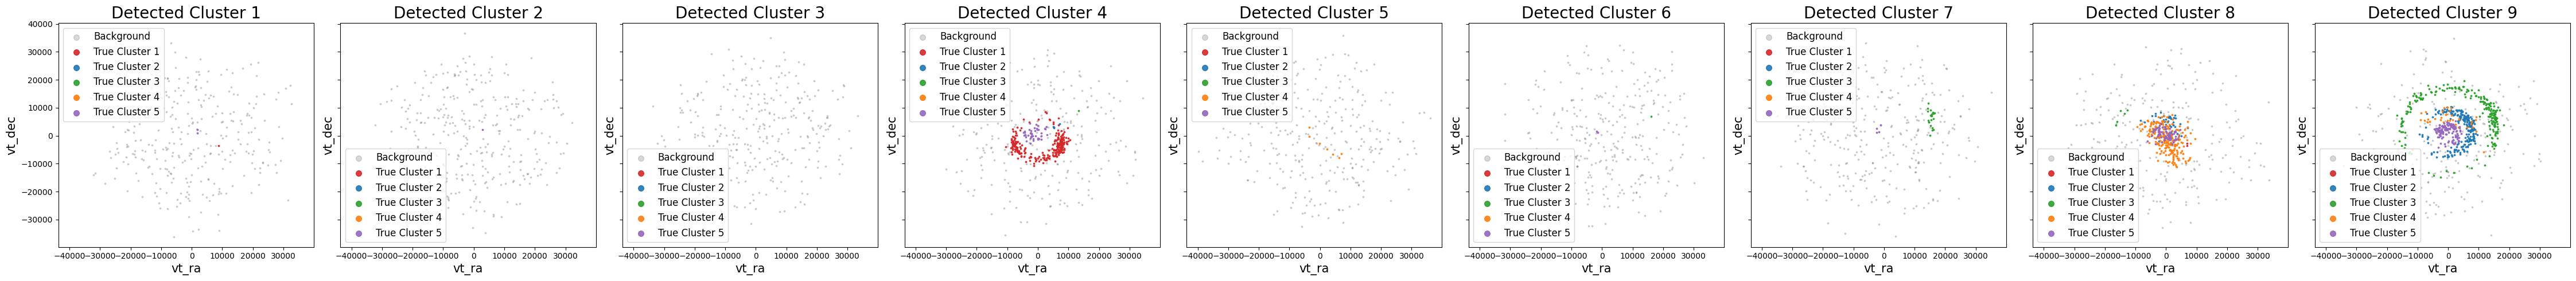

In [8]:
visualisations.visualise_cluster_result(
    df=df,
    cluster_labels=consensus_results,
    true_labels=labels,
    K=len(np.unique(consensus_results)),  
    x_col='vt_ra',
    y_col='vt_dec',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

In [9]:
# Rerun square grid and consensus clustering on specific detected cluster after previous run of the algorithm 
detected_cluster_id = 3
K = 5

clustering_results, subset_df, subset_true_labels, clustering_time = square_grid.rerun_square_grid_clustering_on_detected_cluster(
    df, labels, detected_cluster_id, consensus_results, 
    K, solver, consensus_nclass, num_rotations, shift_vector, num_shifts, 
    grid_size, projection='xy', colors=colors, alphas=alphas, zorders=zorders,
    rotation_axis='z', rotation_angle=None, max_iter=1000, method="random", 
    theta=0.001, epsilon=0.0001, th_dist=5, dist_max=1000, 
    print_info=False, entire_G=False)

In [10]:
overall_nmi = consensus_clusterings.calculate_nmi_and_purity(clustering_results, subset_true_labels, background_label=0)

Overall NMI (ignoring background points): 0.2363

Cluster 0: Only background points present.
  - Number of points: 33

Cluster 1:
  - Number of points: 39
  - Purity (excluding background): 1.0000
  - True label distribution in this cluster:
    * Background noise: 38 points
    * True label 1.0: 1 points


Cluster 2:
  - Number of points: 49
  - Purity (excluding background): 0.8095
  - True label distribution in this cluster:
    * Background noise: 28 points
    * True label 2.0: 3 points
    * True label 3.0: 1 points
    * True label 5.0: 17 points


Cluster 3:
  - Number of points: 48
  - Purity (excluding background): 0.5556
  - True label distribution in this cluster:
    * Background noise: 39 points
    * True label 1.0: 4 points
    * True label 5.0: 5 points


Cluster 4:
  - Number of points: 45
  - Purity (excluding background): 1.0000
  - True label distribution in this cluster:
    * Background noise: 25 points
    * True label 1.0: 20 points


Cluster 5:
  - Number of p

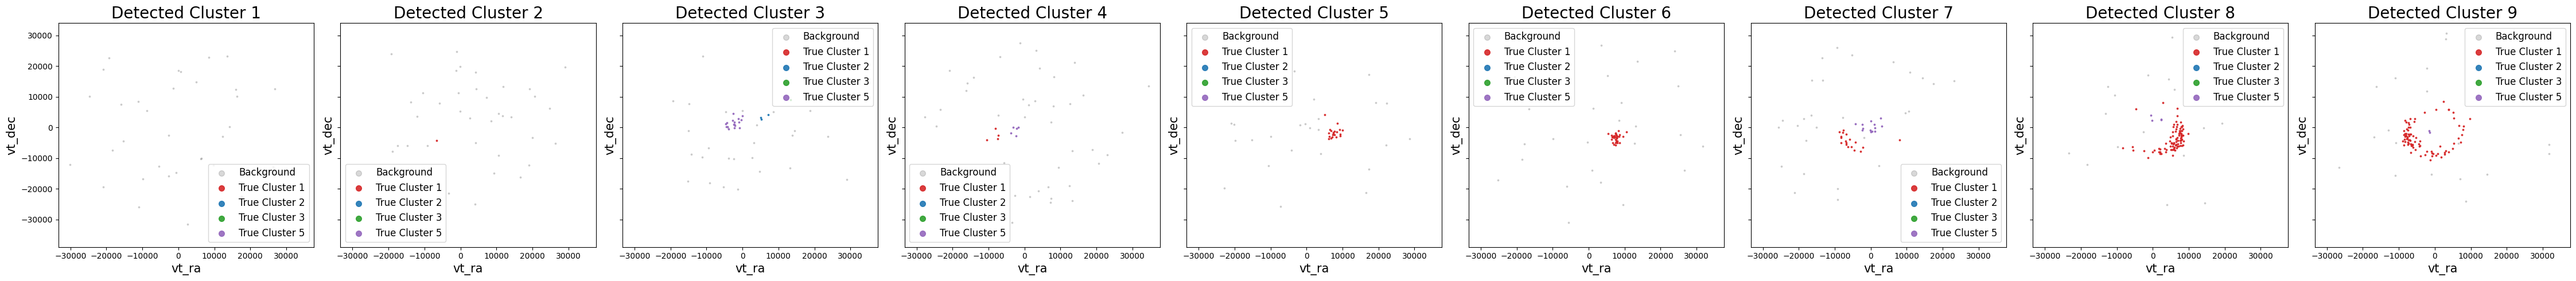

In [11]:
visualisations.visualise_cluster_result(
    df=subset_df,
    cluster_labels=clustering_results,
    true_labels=subset_true_labels,
    K=len(np.unique(clustering_results)),  
    x_col='vt_ra',
    y_col='vt_dec',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

In [15]:
# Try different parameters combinations, save result to csv file; for filtered data from background points
grid_sizes = [10]
shift_vectors = [[3, 3, 3]]
K_values = [9]
solvers = ['cspa', 'hgpa', 'mcla', 'hbgf', 'nmf']
consensus_nclass_values = [9, 6]
num_rotations_values = [3]
rotation_angles = [30]
num_shifts_values = [3]
max_iter_values = [1000]
theta_values = [0.01]
epsilon_values = [0.001]
th_dist_values = [5, 10, 25, None]
dist_max_values = [1000]

In [16]:
results_filtereddf = square_grid.test_square_grid_clustering(df_filtered, labels_filtered, grid_sizes, shift_vectors, K_values, solvers, 
                                consensus_nclass_values, num_rotations_values, rotation_angles, 
                                num_shifts_values, max_iter_values, theta_values, epsilon_values, 
                                th_dist_values, dist_max_values, colors, alphas, zorders, output_csv="clustering_results_filtered_squaregrid.csv")

Testing Square Grid Clustering: 100%|██████████| 40/40 [51:34<00:00, 77.35s/it]   


In [19]:
best_options_filtered, worst_options_filtered = shell_grid.get_best_and_worst_options("clustering_results_filtered_squaregrid.csv", top_n=10)

In [20]:
print("Top 10 best configurations:")
best_options_filtered

Top 10 best configurations:


,Grid Size,Shift Vector,K,Solver,Consensus Nclass,Num Rotations,Rotation Angle,Num Shifts,Max Iter,Theta,Epsilon,Th_dist,Dist_max,Num Clusters,NMI,Runtime (s)
4,10,"[3, 3, 3]",9,cspa,6,3,30,3,1000,0.01,0.001,5.0,1000,6,0.605012,1.868382
7,10,"[3, 3, 3]",9,cspa,6,3,30,3,1000,0.01,0.001,NaN,1000,6,0.589434,1.851409
27,10,"[3, 3, 3]",9,hbgf,9,3,30,3,1000,0.01,0.001,NaN,1000,9,0.579596,1.978041
0,10,"[3, 3, 3]",9,cspa,9,3,30,3,1000,0.01,0.001,5.0,1000,9,0.572299,1.786228
36,10,"[3, 3, 3]",9,nmf,6,3,30,3,1000,0.01,0.001,5.0,1000,6,0.562589,1.227182
6,10,"[3, 3, 3]",9,cspa,6,3,30,3,1000,0.01,0.001,25.0,1000,6,0.554026,1.911217
3,10,"[3, 3, 3]",9,cspa,9,3,30,3,1000,0.01,0.001,NaN,1000,9,0.539647,1.869962
2,10,"[3, 3, 3]",9,cspa,9,3,30,3,1000,0.01,0.001,25.0,1000,9,0.533243,1.877972
24,10,"[3, 3, 3]",9,hbgf,9,3,30,3,1000,0.01,0.001,5.0,1000,9,0.530945,1.958670
26,10,"[3, 3, 3]",9,hbgf,9,3,30,3,1000,0.01,0.001,25.0,1000,9,0.525574,1.903802


In [21]:
print("\nTop 10 worst configurations:")
worst_options_filtered


Top 10 worst configurations:


,Grid Size,Shift Vector,K,Solver,Consensus Nclass,Num Rotations,Rotation Angle,Num Shifts,Max Iter,Theta,Epsilon,Th_dist,Dist_max,Num Clusters,NMI,Runtime (s)
14,10,"[3, 3, 3]",9,hgpa,6,3,30,3,1000,0.01,0.001,25.0,1000,6,0.360779,1.681460
15,10,"[3, 3, 3]",9,hgpa,6,3,30,3,1000,0.01,0.001,NaN,1000,6,0.371779,1.589014
12,10,"[3, 3, 3]",9,hgpa,6,3,30,3,1000,0.01,0.001,5.0,1000,6,0.388967,1.654831
37,10,"[3, 3, 3]",9,nmf,6,3,30,3,1000,0.01,0.001,10.0,1000,6,0.412670,1.255269
23,10,"[3, 3, 3]",9,mcla,6,3,30,3,1000,0.01,0.001,NaN,1000,6,0.431483,375.333226
13,10,"[3, 3, 3]",9,hgpa,6,3,30,3,1000,0.01,0.001,10.0,1000,6,0.435810,1.522786
11,10,"[3, 3, 3]",9,hgpa,9,3,30,3,1000,0.01,0.001,NaN,1000,9,0.446905,1.787928
1,10,"[3, 3, 3]",9,cspa,9,3,30,3,1000,0.01,0.001,10.0,1000,9,0.450463,1.763376
8,10,"[3, 3, 3]",9,hgpa,9,3,30,3,1000,0.01,0.001,5.0,1000,9,0.450941,1.420658
28,10,"[3, 3, 3]",9,hbgf,6,3,30,3,1000,0.01,0.001,5.0,1000,6,0.455267,1.899522


In [25]:
# Try different parameters combinations, save result to csv file; for unfiltered data from background points
grid_sizes = [10]
shift_vectors = [[3, 3, 3]]
K_values = [9]
solvers = ['cspa', 'hbgf', 'nmf']
consensus_nclass_values = [9, 6]
num_rotations_values = [3]
rotation_angles = [30]
num_shifts_values = [3]
max_iter_values = [1000]
theta_values = [0.01]
epsilon_values = [0.001]
th_dist_values = [5, 10, 25, None]
dist_max_values = [1000]

In [38]:
results_nonfiltereddf2 = square_grid.test_square_grid_clustering(df, labels, grid_sizes, shift_vectors, K_values, solvers, 
                                consensus_nclass_values, num_rotations_values, rotation_angles, 
                                num_shifts_values, max_iter_values, theta_values, epsilon_values, 
                                th_dist_values, dist_max_values, colors, alphas, zorders, output_csv="clustering_results_nonfiltered_squaregrid2.csv")

Testing Square Grid Clustering: 100%|██████████| 9/9 [02:25<00:00, 16.16s/it]


In [41]:
best_options_nonfiltered, worst_options_nonfiltered = shell_grid.get_best_and_worst_options("clustering_results_nonfiltered_squaregrid.csv", top_n=10)


In [42]:
print("Top 10 best configurations:")
best_options_nonfiltered

Top 10 best configurations:


,Grid Size,Shift Vector,K,Solver,Consensus Nclass,Num Rotations,Rotation Angle,Num Shifts,Max Iter,Theta,Epsilon,Th_dist,Dist_max,Num Clusters,NMI,Runtime (s)
0,10,"[3, 3, 3]",9,cspa,9,3,30,3,1000,0.01,0.001,5.0,1000,9,0.709153,6.703287
16,10,"[3, 3, 3]",9,nmf,9,3,30,3,1000,0.01,0.001,5.0,1000,9,0.641555,3.738825
3,10,"[3, 3, 3]",9,cspa,9,3,30,3,1000,0.01,0.001,NaN,1000,9,0.588762,6.368603
12,10,"[3, 3, 3]",9,hbgf,6,3,30,3,1000,0.01,0.001,5.0,1000,6,0.578429,11.557429
8,10,"[3, 3, 3]",9,hbgf,9,3,30,3,1000,0.01,0.001,5.0,1000,9,0.574993,11.140711
7,10,"[3, 3, 3]",9,cspa,6,3,30,3,1000,0.01,0.001,NaN,1000,6,0.563663,6.615659
20,10,"[3, 3, 3]",9,nmf,6,3,30,3,1000,0.01,0.001,5.0,1000,6,0.558370,3.417782
13,10,"[3, 3, 3]",9,hbgf,6,3,30,3,1000,0.01,0.001,10.0,1000,6,0.542773,11.446748
5,10,"[3, 3, 3]",9,cspa,6,3,30,3,1000,0.01,0.001,10.0,1000,6,0.542700,6.578347
23,10,"[3, 3, 3]",9,nmf,6,3,30,3,1000,0.01,0.001,NaN,1000,6,0.542299,3.358722


In [43]:
print("\nTop 10 worst configurations:")
worst_options_nonfiltered


Top 10 worst configurations:


,Grid Size,Shift Vector,K,Solver,Consensus Nclass,Num Rotations,Rotation Angle,Num Shifts,Max Iter,Theta,Epsilon,Th_dist,Dist_max,Num Clusters,NMI,Runtime (s)
21,10,"[3, 3, 3]",9,nmf,6,3,30,3,1000,0.01,0.001,10.0,1000,6,0.407948,3.287964
6,10,"[3, 3, 3]",9,cspa,6,3,30,3,1000,0.01,0.001,25.0,1000,6,0.436453,5.924955
2,10,"[3, 3, 3]",9,cspa,9,3,30,3,1000,0.01,0.001,25.0,1000,9,0.445748,6.087657
4,10,"[3, 3, 3]",9,cspa,6,3,30,3,1000,0.01,0.001,5.0,1000,6,0.449685,6.527649
10,10,"[3, 3, 3]",9,hbgf,9,3,30,3,1000,0.01,0.001,25.0,1000,9,0.466559,11.342722
18,10,"[3, 3, 3]",9,nmf,9,3,30,3,1000,0.01,0.001,25.0,1000,9,0.477626,3.538610
11,10,"[3, 3, 3]",9,hbgf,9,3,30,3,1000,0.01,0.001,NaN,1000,9,0.506852,11.540225
17,10,"[3, 3, 3]",9,nmf,9,3,30,3,1000,0.01,0.001,10.0,1000,9,0.507073,3.637074
1,10,"[3, 3, 3]",9,cspa,9,3,30,3,1000,0.01,0.001,10.0,1000,9,0.511270,6.015758
22,10,"[3, 3, 3]",9,nmf,6,3,30,3,1000,0.01,0.001,25.0,1000,6,0.512920,3.296631
